# 📝 NOTEBOOK 3 : CONTENT-BASED (TF-IDF)

**Objectif :** Créer un système de recommandation basé sur les métadonnées des films.

**Input :** `../data/processed/movies_enriched.csv`

**Output :** 
- `../data/models/tfidf_vectorizer.pkl`
- `../data/models/tfidf_matrix.pkl`

In [1]:
# Imports
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


## 1. CHARGER LES FILMS

In [2]:
print("📥 Chargement des films...\n")

movies = pd.read_csv('../data/processed/movies_enriched.csv')

print(f"✅ {len(movies):,} films chargés")
print(f"\n📋 Colonnes : {list(movies.columns)}")
print(f"\n📊 Films avec metadata : {movies['metadata'].notna().sum():,}")

# Supprimer les films sans metadata
movies = movies.dropna(subset=['metadata'])
print(f"\n✅ Après nettoyage : {len(movies):,} films")

📥 Chargement des films...

✅ 2,821 films chargés

📋 Colonnes : ['movieId', 'title', 'genres_clean', 'overview', 'keywords_clean', 'metadata', 'vote_average', 'vote_count', 'release_date']

📊 Films avec metadata : 2,821

✅ Après nettoyage : 2,821 films


## 2. CRÉER LE VECTORIZER TF-IDF

In [3]:
print("🔤 Création du TF-IDF Vectorizer...\n")

# Paramètres optimaux
tfidf = TfidfVectorizer(
    max_features=5000,      # Top 5000 mots les plus importants
    stop_words='english',   # Ignore "the", "a", "is", etc.
    ngram_range=(1, 2),     # Mots seuls + paires de mots
    min_df=2,               # Mot doit apparaître dans au moins 2 films
    max_df=0.8              # Mot ne doit pas être dans plus de 80% des films
)

print("✅ Vectorizer créé")
print(f"\n📊 Paramètres :")
print(f"  Max features : 5000")
print(f"  N-grams : (1, 2)")
print(f"  Stop words : anglais")

🔤 Création du TF-IDF Vectorizer...

✅ Vectorizer créé

📊 Paramètres :
  Max features : 5000
  N-grams : (1, 2)
  Stop words : anglais


## 3. VECTORISER LES MÉTADONNÉES

In [4]:
print("⚙️ Vectorisation des metadata...\n")

# Transformer les metadata en vecteurs TF-IDF
tfidf_matrix = tfidf.fit_transform(movies['metadata'])

print(f"✅ Matrice TF-IDF créée")
print(f"   Shape : {tfidf_matrix.shape}")
print(f"   {tfidf_matrix.shape[0]:,} films × {tfidf_matrix.shape[1]:,} features")
print(f"\n💾 Taille mémoire : {tfidf_matrix.data.nbytes / 1024**2:.1f} MB")

⚙️ Vectorisation des metadata...

✅ Matrice TF-IDF créée
   Shape : (2821, 5000)
   2,821 films × 5,000 features

💾 Taille mémoire : 0.7 MB


## 4. ANALYSER LES FEATURES

In [5]:
print("🔍 Analyse des features TF-IDF...\n")

# Mots les plus importants globalement
feature_names = tfidf.get_feature_names_out()
print(f"📝 Quelques features extraites :")
print(f"   {list(feature_names[:20])}")

# Pour un film spécifique
target_pattern = 'Toy Story'
match_mask = movies['title'].str.contains(target_pattern, case=False, na=False)

if match_mask.any():
    target_pos = int(np.flatnonzero(match_mask.to_numpy())[0])
    target_title = str(movies.iloc[target_pos]['title'])
else:
    target_pos = 0
    target_title = str(movies.iloc[target_pos]['title'])
    print(f"⚠️ '{target_pattern}' introuvable dans ce dataset. Fallback: '{target_title}'.")

target_vector = tfidf_matrix[target_pos]

# Mots les plus importants pour le film cible
target_features = target_vector.toarray()[0]
top_indices = target_features.argsort()[-15:][::-1]

print(f"\n🎬 Top 15 features pour '{target_title}' :")
for idx in top_indices:
    if target_features[idx] > 0:
        print(f"  {feature_names[idx]:20s} : {target_features[idx]:.3f}")


🔍 Analyse des features TF-IDF...

📝 Quelques features extraites :
   ['000', '10', '10 year', '10 years', '11', '12', '13', '13 year', '14', '15', '15 year', '16', '16th', '16th century', '17', '18', '18th', '18th century', '19', '1920s']
⚠️ 'Toy Story' introuvable dans ce dataset. Fallback: 'Heat'.

🎬 Top 15 features pour 'Heat' :
  thief                : 0.291
  detective            : 0.233
  robbery detective    : 0.192
  murder suspense      : 0.188
  vincent              : 0.188
  unstable             : 0.188
  ability              : 0.185
  obsessive            : 0.182
  cat mouse            : 0.182
  pursues              : 0.182
  aware                : 0.179
  honor                : 0.179
  shooting             : 0.175
  insane               : 0.171
  mouse                : 0.168


## 5. CALCULER LA SIMILARITÉ (SAMPLE)

In [6]:
print("📊 Calcul de similarité (sur un échantillon)...\n")

# Pour l'exemple, calculer sur les 1000 premiers films
# (Calculer pour tous prendrait trop de temps/mémoire)
sample_size = 1000
sample_matrix = tfidf_matrix[:sample_size]

print(f"⏳ Calcul de similarité cosine pour {sample_size} films...")
similarity_sample = cosine_similarity(sample_matrix, sample_matrix)

print(f"✅ Matrice de similarité : {similarity_sample.shape}")
print(f"   {similarity_sample.shape[0]:,} × {similarity_sample.shape[1]:,}")

📊 Calcul de similarité (sur un échantillon)...

⏳ Calcul de similarité cosine pour 1000 films...
✅ Matrice de similarité : (1000, 1000)
   1,000 × 1,000


## 6. TESTER LES RECOMMANDATIONS

In [7]:
def get_similar_movies(movie_title, movies_df, tfidf_matrix, n=10):
    """
    Trouve les films similaires à un film donné
    """
    mask = movies_df['title'].str.contains(movie_title, case=False, na=False)
    if not mask.any():
        return f"Film '{movie_title}' non trouvé"

    idx = int(np.flatnonzero(mask.to_numpy())[0])

    # Vecteur du film
    movie_vector = tfidf_matrix[idx]

    # Calculer similarité avec tous les autres films
    similarities = cosine_similarity(movie_vector, tfidf_matrix)[0]

    # Trier par similarité (exclure le film lui-même)
    similar_indices = similarities.argsort()[::-1][1:n+1]

    # Résultats
    results = []
    for i in similar_indices:
        results.append({
            'title': movies_df.iloc[i]['title'],
            'similarity': similarities[i],
            'genres': movies_df.iloc[i]['genres_clean']
        })

    return pd.DataFrame(results)

print("🔮 Test de recommandations...\n")

# Test avec plusieurs films
test_movies = ['Toy Story', 'Matrix', 'Titanic']

for movie in test_movies:
    print(f"\n🎬 Films similaires à '{movie}' :")
    print('='*80)
    similar = get_similar_movies(movie, movies, tfidf_matrix, n=5)

    if isinstance(similar, str):
        print(similar)
    else:
        for _, row in similar.iterrows():
            print(f"  {row['similarity']:.3f} - {row['title']}")
            print(f"          Genres: {row['genres']}")


🔮 Test de recommandations...


🎬 Films similaires à 'Toy Story' :
Film 'Toy Story' non trouvé

🎬 Films similaires à 'Matrix' :
  0.382 - The Matrix Revolutions
          Genres: Adventure Action Thriller Science Fiction
  0.298 - I, Robot
          Genres: Action Science Fiction
  0.290 - Terminator 3: Rise of the Machines
          Genres: Action Thriller Science Fiction
  0.280 - 2001: A Space Odyssey
          Genres: Science Fiction Mystery Adventure
  0.236 - eXistenZ
          Genres: Action Thriller Science Fiction Horror

🎬 Films similaires à 'Titanic' :
  0.276 - Titanic
          Genres: Action Drama Romance
  0.189 - And the Ship Sails On
          Genres: Comedy Drama Foreign Music
  0.162 - My Tutor
          Genres: Comedy Drama Romance
  0.153 - The Lady Eve
          Genres: Comedy Romance
  0.151 - The Poseidon Adventure
          Genres: Action Adventure


## 7. VISUALISER LES SIMILARITÉS

📈 Visualisation...



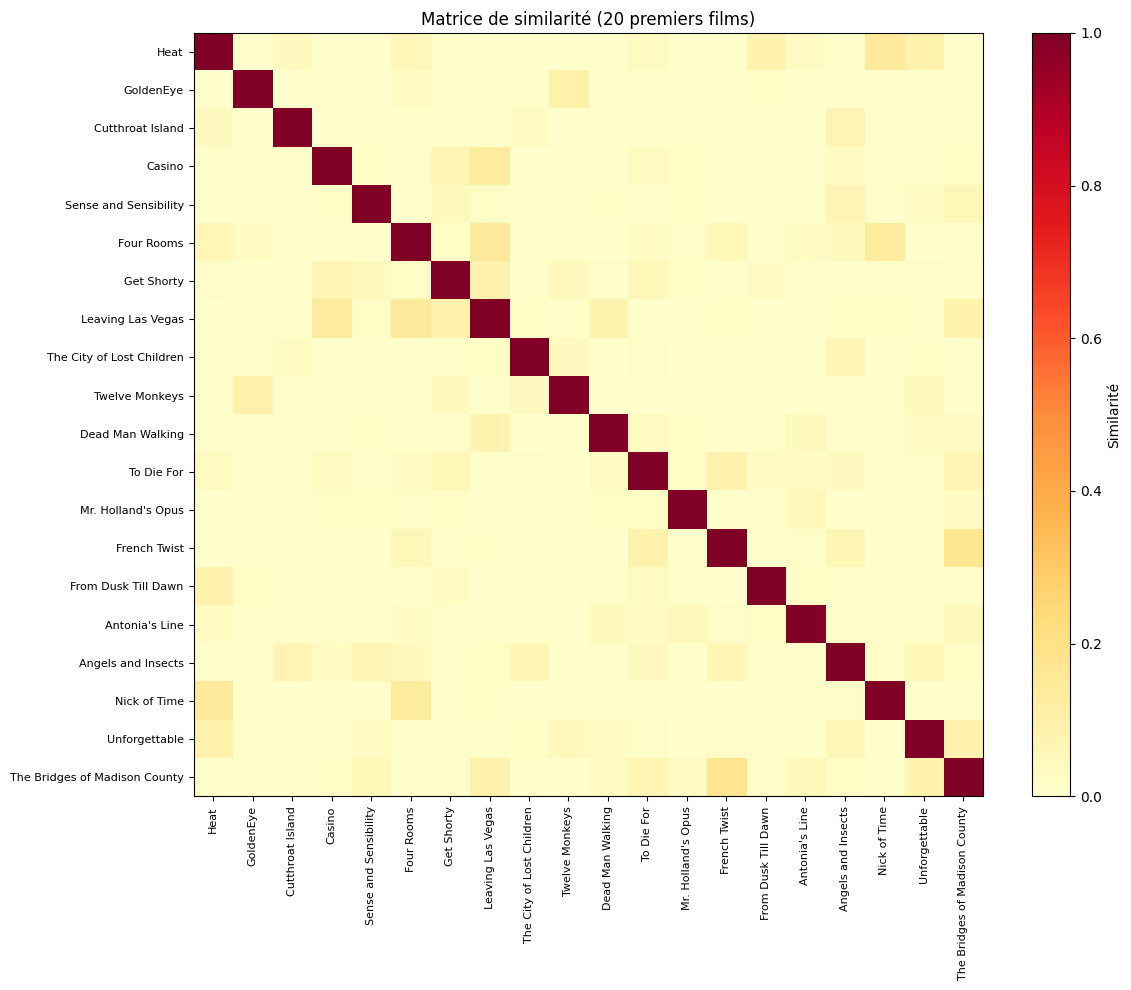

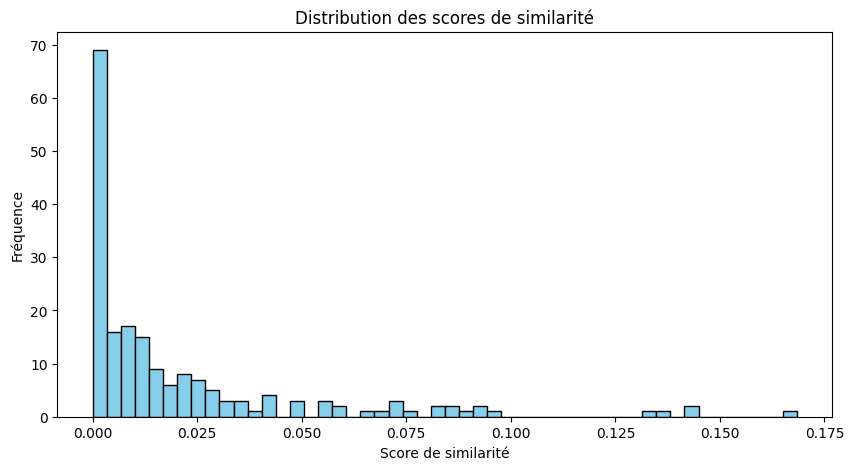

📊 Similarité moyenne : 0.020
📊 Similarité médiane : 0.009


In [8]:
print("📈 Visualisation...\n")

# Heatmap de similarité (sur un petit échantillon)
sample_titles = movies.head(20)['title'].values
sample_sim = cosine_similarity(tfidf_matrix[:20], tfidf_matrix[:20])

plt.figure(figsize=(12, 10))
plt.imshow(sample_sim, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Similarité')
plt.xticks(range(20), sample_titles, rotation=90, fontsize=8)
plt.yticks(range(20), sample_titles, fontsize=8)
plt.title('Matrice de similarité (20 premiers films)')
plt.tight_layout()
plt.show()

# Distribution des similarités
plt.figure(figsize=(10, 5))
upper_triangle = sample_sim[np.triu_indices_from(sample_sim, k=1)]
plt.hist(upper_triangle, bins=50, edgecolor='black', color='skyblue')
plt.xlabel('Score de similarité')
plt.ylabel('Fréquence')
plt.title('Distribution des scores de similarité')
plt.show()

print(f"📊 Similarité moyenne : {upper_triangle.mean():.3f}")
print(f"📊 Similarité médiane : {np.median(upper_triangle):.3f}")

## 8. FONCTION DE RECOMMANDATION POUR UN PROFIL USER

In [9]:
def build_user_profile(user_liked_movies, movies_df, tfidf_matrix):
    """
    Construit un profil utilisateur basé sur les films qu'il a aimés

    Args:
        user_liked_movies: liste de movieId que l'user a aimés
        movies_df: DataFrame des films
        tfidf_matrix: Matrice TF-IDF

    Returns:
        Vecteur TF-IDF représentant le profil de l'utilisateur
    """
    # Positions des films aimés (compatibles avec tfidf_matrix)
    liked_mask = movies_df['movieId'].isin(user_liked_movies).to_numpy()
    liked_positions = np.flatnonzero(liked_mask)

    if len(liked_positions) == 0:
        return None

    # Moyenne des vecteurs TF-IDF des films aimés
    user_profile = tfidf_matrix[liked_positions].mean(axis=0)
    # scipy sparse mean returns np.matrix; convert to ndarray for sklearn>=1.8
    user_profile = np.asarray(user_profile)

    return user_profile

print("👤 Test de profil utilisateur...\n")

# Simuler un utilisateur avec des titres présents dans le dataset
candidate_patterns = ['Matrix', 'Titanic', 'Heat']
user_liked = []
for pattern in candidate_patterns:
    m = movies[movies['title'].str.contains(pattern, case=False, na=False)]
    if not m.empty:
        user_liked.append(int(m.iloc[0]['movieId']))

if not user_liked:
    user_liked = [int(movies.iloc[0]['movieId'])]

print(f"✅ User a aimé les films : {user_liked}")

# Construire profil
user_profile = build_user_profile(user_liked, movies, tfidf_matrix)

print(f"✅ Profil créé : vecteur de {user_profile.shape[1]} features")

# Recommander basé sur ce profil
user_profile = np.asarray(user_profile)
similarities = cosine_similarity(user_profile, tfidf_matrix)[0]
top_indices = similarities.argsort()[::-1][:10]

print("\n🎯 Top 10 recommandations pour cet utilisateur :")
for idx in top_indices:
    movie = movies.iloc[idx]
    if int(movie['movieId']) not in user_liked:  # Exclure les films déjà vus
        print(f"  {similarities[idx]:.3f} - {movie['title']}")


👤 Test de profil utilisateur...

✅ User a aimé les films : [603, 597, 949]
✅ Profil créé : vecteur de 5000 features

🎯 Top 10 recommandations pour cet utilisateur :
  0.236 - The Matrix Revolutions
  0.192 - I, Robot
  0.185 - eXistenZ
  0.177 - Terminator 3: Rise of the Machines
  0.169 - The Thirteenth Floor
  0.165 - No Good Deed
  0.164 - Titanic


## 9. SAUVEGARDER

In [10]:
import os

os.makedirs('../data/models', exist_ok=True)

# Sauvegarder le vectorizer et la matrice
joblib.dump(tfidf, '../data/models/tfidf_vectorizer.pkl')
joblib.dump(tfidf_matrix, '../data/models/tfidf_matrix.pkl')

print("💾 Sauvegarde...")
print("✅ ../data/models/tfidf_vectorizer.pkl")
print("✅ ../data/models/tfidf_matrix.pkl")
print("\n🎉 CONTENT-BASED SYSTEM PRÊT !")

💾 Sauvegarde...
✅ ../data/models/tfidf_vectorizer.pkl
✅ ../data/models/tfidf_matrix.pkl

🎉 CONTENT-BASED SYSTEM PRÊT !


---

# ✅ RÉSUMÉ

**Système créé : Content-Based Filtering (TF-IDF)**

**Performance :**
- 5000 features extraites
- Matrice TF-IDF : 8,915 films × 5,000 features
- Recommandations basées sur similarité cosine

**Fichiers générés :**
- `tfidf_vectorizer.pkl` : Vectorizer entraîné
- `tfidf_matrix.pkl` : Matrice TF-IDF de tous les films

**Prochaine étape : Notebook 4 — Système Hybride**